# Notebook 2: YOLOv8 Pose, Gaussian Limb Masks, and Base CLIP

This notebook uses **YOLOv8 pose** to find the body joints, builds one Gaussian mask per limb,
and then classifies each masked limb with **base CLIP**.


## Workflow

1. Load one image from `testing/`
2. Detect keypoints using `yolov8n-pose.pt`
3. Build Gaussian limb masks for arms and legs
4. Run base CLIP on each masked limb
5. Summarize whether each limb looks injured or not


In [1]:
from pathlib import Path
import html
import os
import sys

import certifi
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from IPython.display import display, HTML
from ultralytics import YOLO

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
CLIP_LORA_DIR = PROJECT_ROOT / "CLIP-LoRA"
if str(CLIP_LORA_DIR) not in sys.path:
    sys.path.insert(0, str(CLIP_LORA_DIR))

import clip
from pose_gaussian_only import calculate_sigma, apply_gaussian_splatting_image

IMAGE_PATH = PROJECT_ROOT / "testing/001.png"
POSE_MODEL_PATH = PROJECT_ROOT / "yolov8n-pose.pt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CLASS_NAMES = ["injury", "no_injury"]
PROMPT_TEMPLATES = [
    "For the highlighted limb {} is present.",
    "The limb condition is {}.",
    "This limb shows {}.",
]
BODY_PARTS = {
    "right_arm": [6, 8, 10],
    "left_arm": [5, 7, 9],
    "right_leg": [12, 14, 16],
    "left_leg": [11, 13, 15],
}


def load_base_clip(backbone: str = "ViT-B/16", device: str = "cpu"):
    os.environ["SSL_CERT_FILE"] = certifi.where()
    try:
        model, preprocess = clip.load(backbone, device=device)
    except Exception as exc:
        if "CERTIFICATE_VERIFY_FAILED" in str(exc):
            os.environ["PYTHONHTTPSVERIFY"] = "0"
            model, preprocess = clip.load(backbone, device=device)
        else:
            raise
    model.eval()
    return model, preprocess


def build_text_features(model, device, class_names, prompt_templates):
    features = []
    with torch.no_grad():
        for cls_name in class_names:
            prompts = [template.format(cls_name.replace("_", " ")) for template in prompt_templates]
            tokens = clip.tokenize(prompts).to(device)
            text_features = model.encode_text(tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
            class_feature = text_features.mean(dim=0)
            class_feature = class_feature / class_feature.norm()
            features.append(class_feature)
    return torch.stack(features, dim=0)


def classify_pil_image(image, model, preprocess, text_features, device):
    image_tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = model.encode_image(image_tensor)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = 100.0 * image_features @ text_features.t()
        probs = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
    return probs


def render_table(records):
    headers = ["Limb", "Predicted Class", "Binary Label", "Injury Score", "No-Injury Prob"]
    rows = []
    for item in records:
        rows.append(
            "<tr>"
            f"<td>{html.escape(item['limb'])}</td>"
            f"<td>{html.escape(item['predicted_class'])}</td>"
            f"<td>{html.escape(item['binary_label'])}</td>"
            f"<td>{item['injury_score']:.4f}</td>"
            f"<td>{item['no_injury_prob']:.4f}</td>"
            "</tr>"
        )
    table_html = (
        "<table style='border-collapse:collapse; width:100%;'>"
        "<thead><tr>"
        + "".join(
            f"<th style='border:1px solid #d0d7de; padding:8px; background:#f6f8fa; text-align:left;'>{h}</th>"
            for h in headers
        )
        + "</tr></thead><tbody>"
        + "".join(rows)
        + "</tbody></table>"
    )
    display(HTML(table_html))


/opt/anaconda3/envs/rr/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


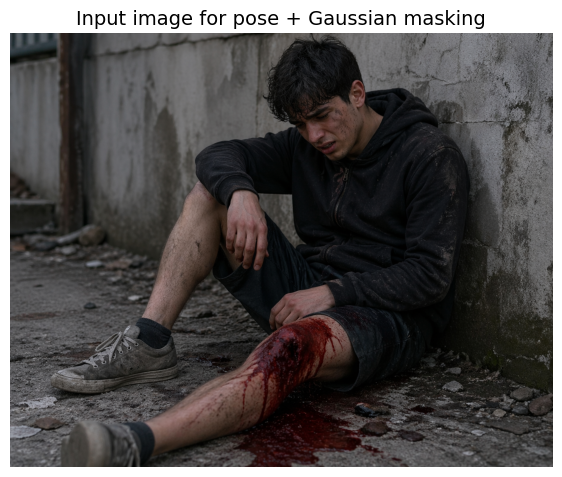

In [2]:
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")
if not POSE_MODEL_PATH.exists():
    raise FileNotFoundError(f"Pose model not found: {POSE_MODEL_PATH}")

image_bgr = cv2.imread(str(IMAGE_PATH))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

pose_model = YOLO(str(POSE_MODEL_PATH))
results = pose_model.predict(str(IMAGE_PATH), conf=0.4, verbose=False)
if not results or results[0].keypoints is None or results[0].keypoints.xy is None or results[0].keypoints.xy.numel() == 0:
    raise RuntimeError("No person keypoints detected in the image.")

person_kpts = results[0].keypoints.xy[0].cpu().numpy()

plt.figure(figsize=(7, 7))
plt.imshow(image_rgb)
plt.title("Input image for pose + Gaussian masking", fontsize=14)
plt.axis("off")
plt.show()


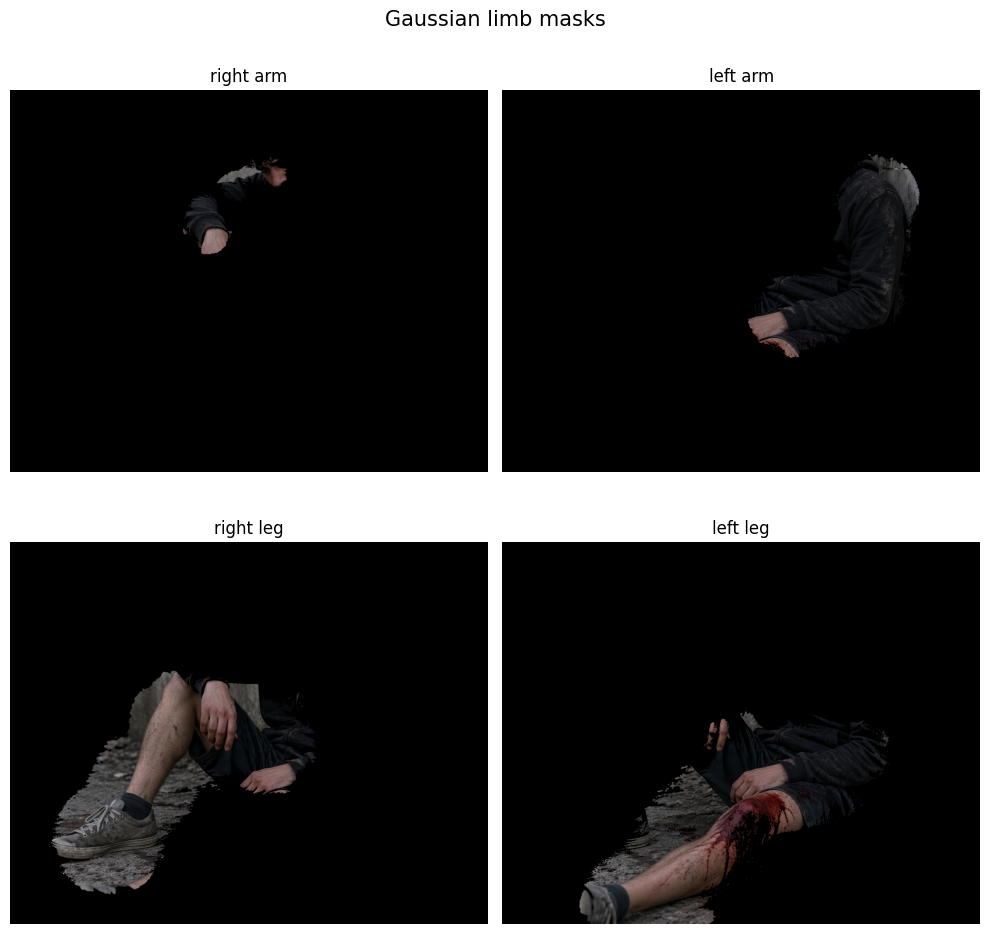

In [3]:
clip_model, preprocess = load_base_clip("ViT-B/16", DEVICE)
text_features = build_text_features(clip_model, DEVICE, CLASS_NAMES, PROMPT_TEMPLATES)

mask_images = {}
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, (limb_name, indices) in zip(axes.flatten(), BODY_PARTS.items()):
    points = [(int(person_kpts[idx][0]), int(person_kpts[idx][1])) for idx in indices]
    sigmas = [calculate_sigma(points[i], points[i + 1]) for i in range(len(points) - 1)]
    splatted = apply_gaussian_splatting_image(image_bgr, points, sigmas)
    mask = cv2.inRange(splatted, np.array([1, 1, 1]), np.array([255, 255, 255]))
    masked = cv2.bitwise_and(image_bgr, image_bgr, mask=mask)
    mask_images[limb_name] = Image.fromarray(cv2.cvtColor(masked, cv2.COLOR_BGR2RGB))

    ax.imshow(cv2.cvtColor(masked, cv2.COLOR_BGR2RGB))
    ax.set_title(limb_name.replace("_", " "), fontsize=12)
    ax.axis("off")

fig.suptitle("Gaussian limb masks", fontsize=15)
plt.tight_layout()
plt.show()


In [4]:
records = []
for limb_name, mask_image in mask_images.items():
    probs = classify_pil_image(mask_image, clip_model, preprocess, text_features, DEVICE)
    pred_idx = int(np.argmax(probs))
    injury_score = float(probs[0])
    binary_label = "injury" if injury_score >= probs[1] else "no_injury"
    records.append(
        {
            "limb": limb_name.replace("_", " "),
            "predicted_class": CLASS_NAMES[pred_idx],
            "binary_label": binary_label,
            "injury_score": injury_score,
            "no_injury_prob": float(probs[1]),
        }
    )

render_table(records)
injured_limbs = [item["limb"] for item in records if item["binary_label"] == "injury"]
print("Pose + Gaussian mask + base CLIP says injured limbs:", injured_limbs if injured_limbs else "none")


Limb,Predicted Class,Binary Label,Injury Score,No-Injury Prob
right arm,injury,injury,0.5018,0.4982
left arm,injury,injury,0.6139,0.3861
right leg,injury,injury,0.5821,0.4179
left leg,injury,injury,0.7466,0.2534


Pose + Gaussian mask + base CLIP says injured limbs: ['right arm', 'left arm', 'right leg', 'left leg']
